In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '5'
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from pathlib import Path
from glob import glob
import numpy as np
import sys
import matplotlib as mpl
from photutils.centroids import centroid_quadratic
from time import time
from scipy import interpolate
from scipy import ndimage,signal
from PyAstronomy.pyasl import crosscorrRV
from scipy.interpolate import UnivariateSpline
from skimage.registration import phase_cross_correlation

In [2]:
from spyffier import Pipeline
from spyffier.utils import calibrate_wavelength_frame,plot_data,plot_spectrum,diagnostic_wvl_solution,get_sky_calc_model

In [3]:
# path where esorex is installed
esorex_path = '/home/ipa/quanz/user_accounts/jhayoz/ESO_2024-07-22/bin/esorex'
# path to the root of where the data created by the pipeline should be saved
reduction_path = '/home/ipa/quanz/user_accounts/jhayoz/Projects/SpyFFIER/example_pipeline/'
# path to where the raw data is
raw_path = '/home/ipa/quanz/shared/eris/P112_atmospheres/HR8799/2023_10_14/raw/'

In [4]:
pipeline = Pipeline(esorex_path = esorex_path, reduction_path = reduction_path, raw_path = raw_path, wavel_setting = 'K_long')

Data reduction folder: /home/ipa/quanz/user_accounts/jhayoz/Projects/SpyFFIER/example_pipeline
Manually set spectral setting: K_long
Reading header data from header.csv
Creating dictionary for filenames

Available EsoRex recipes for ERIS/SPIFFIER:
   -  eris_ifu_distortion   : This recipe performs distortion correction
   -  eris_ifu_detlin       : Detector's linearity & non linear bad pixels
   -  eris_ifu_jitter       : This recipe reconstruct data cubes from object
   -  eris_ifu_pupil        : This recipe reconstruct data cubes from std stars
   -  eris_ifu_stdstar      : This recipe reconstruct data cubes from std stars
   -  eris_ifu_dark         : This recipe perform dark data reduction
   -  eris_ifu_flat         : This recipe performs flat field data reduction
   -  eris_ifu_combine      : This recipe combines jittered cubes into a single cube
   -  eris_ifu_combine_hdrl : Combine science cubes using hdrl
   -  eris_ifu_wavecal      : This recipe performs the wavelength calibr

# Execute the reduction with the standard pipeline


-----------------------
Extracting FITS headers
-----------------------

Creating new DataFrame...

Exporting DataFrame to header.csv
Exporting DataFrame to header.xlsx

-------------------
Observation details
-------------------

Target = HD 218396
Program ID = 112.2628.001
Grating wheel = K_long
Pixel scale = 25mas

Observation ID:
   - 3293324.0 -> 212 files
   - 3762978.0 -> 40 files

------------------
Create master DARK
------------------

EsoRex recipe: eris_ifu_dark

Verbose: True
Create SOF: True

Only considering DIT values: 15.0

Creating SOF file:
   - raw/ERIS.2023-10-16T09:58:08.705.fits DARK
   - raw/ERIS.2023-10-16T09:58:28.699.fits DARK
   - raw/ERIS.2023-10-16T09:58:48.699.fits DARK
   - raw/ERIS.2023-10-16T09:59:08.642.fits DARK
   - raw/ERIS.2023-10-16T09:59:28.710.fits DARK
   - raw/ERIS.2023-10-16T09:59:49.410.fits DARK
   - raw/ERIS.2023-10-16T10:01:01.078.fits DARK
   - raw/ERIS.2023-10-16T10:02:14.626.fits DARK
   - raw/ERIS.2023-10-16T10:03:26.918.fits DARK
 

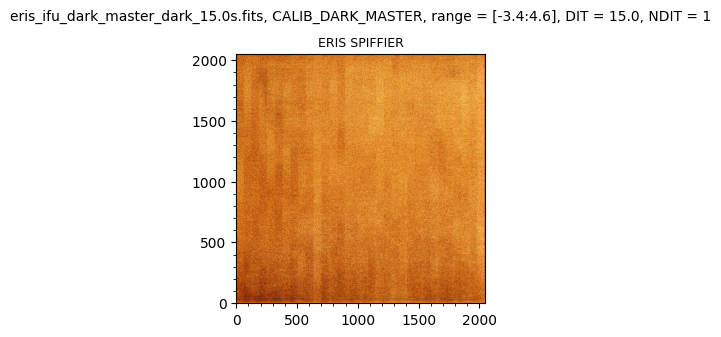


------------------
Create master DARK
------------------

EsoRex recipe: eris_ifu_dark

Verbose: True
Create SOF: True

Only considering DIT values: 30.0

Creating SOF file:
   - raw/ERIS.2023-10-16T10:05:51.079.fits DARK
   - raw/ERIS.2023-10-16T10:15:33.598.fits DARK
   - raw/ERIS.2023-10-16T10:25:16.149.fits DARK
   - raw/ERIS.2023-10-16T10:34:58.813.fits DARK
   - raw/ERIS.2023-10-16T10:44:41.367.fits DARK
   - raw/ERIS.2023-10-16T10:54:24.608.fits DARK
   - raw/ERIS.2023-10-16T10:55:31.866.fits DARK
   - raw/ERIS.2023-10-16T10:56:39.108.fits DARK
   - raw/ERIS.2023-10-16T10:57:46.376.fits DARK
   - raw/ERIS.2023-10-16T10:58:53.548.fits DARK


     ***** ESO Recipe Execution Tool, version 3.13.8  *****

[ INFO  ] eris_ifu_dark: Reading recipe parameters
[ INFO  ] eris_ifu_dark: Loading set of frames (SOF)
[ INFO  ] eris_ifu_dark: Generate master dark image
[ INFO  ] eris_ifu_dark: Generate noise image
[ INFO  ] eris_ifu_dark: Generating 2D bad pixel mask...
[ INFO  ] eris_ifu_dark

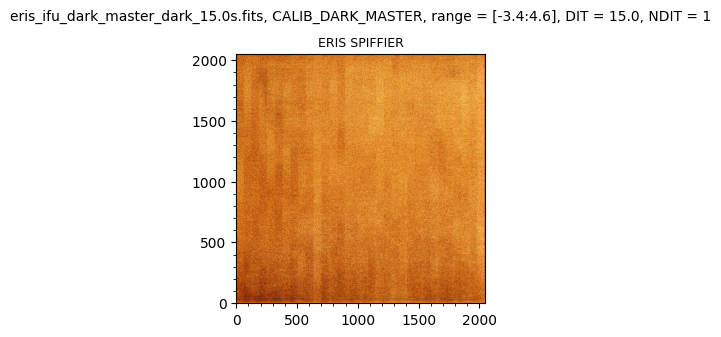

   - calib/calib_dark/eris_ifu_dark_master_dark_30.0s.png


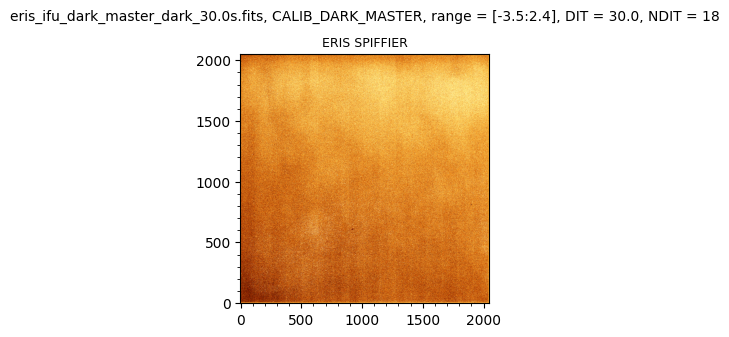


-------------
Create DETLIN
-------------

EsoRex recipe: eris_ifu_detlin

Verbose: True
Create SOF: True

Unique DIT values: {1.644385, 2.2, 3.0, 2.6, 1.9, 3.5, 4.0, 4.7, 5.5, 6.3, 7.4, 8.6, 9.9, 11.5, 13.4, 15.6, 18.1, 21.0, 24.4, 28.4, 32.9, 38.3, 44.5, 51.6, 60.0}

Creating SOF file:
   - raw/ERIS.2023-09-22T11:34:17.461.fits LINEARITY_LAMP
   - raw/ERIS.2023-09-22T11:34:24.094.fits LINEARITY_LAMP
   - raw/ERIS.2023-09-22T11:34:30.755.fits LINEARITY_LAMP
   - raw/ERIS.2023-09-22T11:34:37.654.fits LINEARITY_LAMP
   - raw/ERIS.2023-09-22T11:34:45.477.fits LINEARITY_LAMP
   - raw/ERIS.2023-09-22T11:34:52.770.fits LINEARITY_LAMP
   - raw/ERIS.2023-09-22T11:34:59.970.fits LINEARITY_LAMP
   - raw/ERIS.2023-09-22T11:35:07.600.fits LINEARITY_LAMP
   - raw/ERIS.2023-09-22T11:35:15.457.fits LINEARITY_LAMP
   - raw/ERIS.2023-09-22T11:35:23.492.fits LINEARITY_LAMP
   - raw/ERIS.2023-09-22T11:35:31.520.fits LINEARITY_LAMP
   - raw/ERIS.2023-09-22T11:35:40.011.fits LINEARITY_LAMP
   - raw/ERIS.

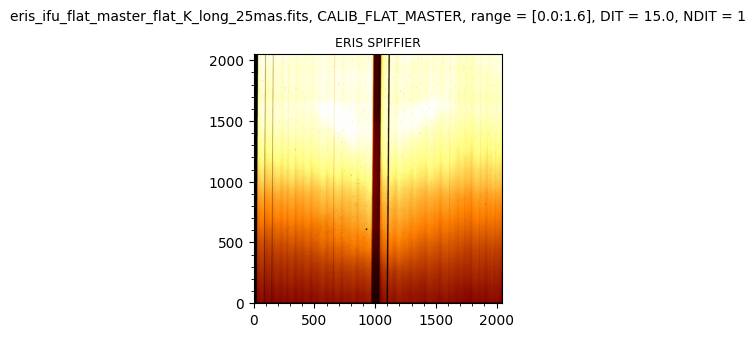


--------------
Create WAVECAL
--------------

EsoRex recipe: eris_ifu_wavecal

Verbose: True
Create SOF: True

Creating SOF file:
   - raw/ERIS.2023-10-16T11:09:19.654.fits WAVE_LAMP
   - raw/ERIS.2023-10-16T11:15:30.894.fits WAVE_LAMP
   - raw/ERIS.2023-10-16T11:21:49.870.fits WAVE_LAMP
   - calib/calib_flat/eris_ifu_flat_master_flat_K_long_25mas.fits CALIB_FLAT_MASTER
   - calib/calib_distortion/eris_ifu_distortion_distortion_K_long_25mas.fits CALIB_DISTORTION_DISTORTION
   - raw/M.ERIS.2022-12-12T12:36:00.146.fits FIRST_WAVE_FIT
   - raw/M.ERIS.2022-12-22T10:16:54.240.fits REF_LINE_ARC
   - raw/M.ERIS.2022-12-12T12:36:10.023.fits WAVE_SETUP


     ***** ESO Recipe Execution Tool, version 3.13.8  *****

[ INFO  ] esorex: Creating configuration file '/home/ipa/quanz/user_accounts/jhayoz/Projects/SpyFFIER/example_pipeline/calib/calib_wavecal/calib_wavecal.rc'


     ***** ESO Recipe Execution Tool, version 3.13.8  *****

[ INFO  ] eris_ifu_wavecal: Reading recipe parameters
[ INFO  ] 

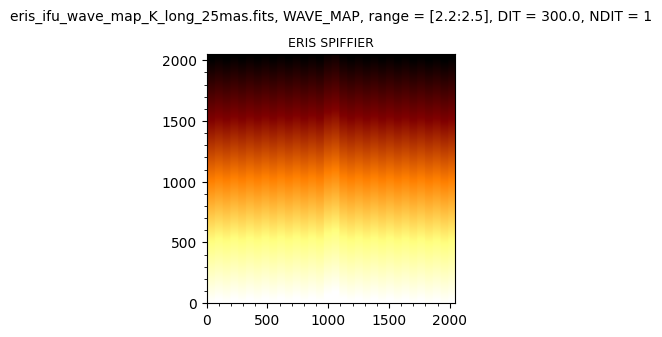

In [5]:
pipeline.do_standard_reduction(
    spiffier_gw ='K_long',
    spiffier_psw = '25mas'
)

# Execute science_ifu_jitter a first time

In [6]:
unique_dit_ndit = pipeline._identify_science_dit_ndit()

In [7]:
dit,ndit = unique_dit_ndit[1]
ndit=int(ndit)

In [9]:
# identify the SKY-OBJ pair groups
# here only one group, as there are no SKY frames in this observation
files_groups = pipeline._identify_obj_sky_groups_by_time(obj_tag = 'OBJECT',sky_tag = 'SKY', dit = dit, ndit = ndit,spiffier_gw = 'K_long', spiffier_psw = '25mas')

(30.0, 18, 'K_long', '25mas') # OBJECT: 23, # SKY: 0


In [10]:
# overwrite the configuration
# Any argument that is used by the science_ifu_jitter can be changed here
new_config = {'cube.combine':'FALSE','aj-method':0,'sky_tweak':'0','skip_sky_oh_align':'TRUE','tbsub':'TRUE','skip_oh_align':'TRUE'}

In [ ]:
for files_group_i in files_groups.keys():
    obj_files = [file for file_i,file in enumerate(files_groups[files_group_i]['OBJECT'])]
    sky_files = [file for file_i,file in enumerate(files_groups[files_group_i]['SKY'])]
    pipeline.science_ifu_jitter(dit = dit, ndit = ndit,spiffier_gw = 'K_long', spiffier_psw = '25mas', obj_date_obs = obj_files, sky_date_obs = sky_files,new_config=new_config, output_name = f'product_g_{files_group_i}', use_corr_wavemap = None)


-------------------
Create SCIENCE CUBE
-------------------

EsoRex recipe: eris_ifu_jitter

Verbose: True
Create SOF: True

Creating SOF file:
   - raw/ERIS.2023-10-16T00:29:07.690.fits OBJ
   - raw/ERIS.2023-10-16T00:38:01.133.fits OBJ
   - raw/ERIS.2023-10-16T00:42:28.880.fits OBJ
   - raw/ERIS.2023-10-16T00:53:49.913.fits OBJ
   - raw/ERIS.2023-10-16T00:57:17.692.fits OBJ
   - raw/ERIS.2023-10-16T01:21:00.059.fits OBJ
   - raw/ERIS.2023-10-16T02:11:17.031.fits OBJ
   - raw/ERIS.2023-10-16T02:22:38.800.fits OBJ
   - raw/ERIS.2023-10-16T02:31:00.918.fits OBJ
   - raw/ERIS.2023-10-16T02:41:31.471.fits OBJ
   - calib/calib_distortion/eris_ifu_distortion_distortion_K_long_25mas.fits CALIB_DISTORTION_DISTORTION
   - calib/calib_distortion/eris_ifu_distortion_slitlet_pos_K_long_25mas.fits CALIB_DISTORTION_SLITLET_POS
   - calib/calib_flat/eris_ifu_flat_master_flat_K_long_25mas.fits CALIB_FLAT_MASTER
   - calib/calib_dark/eris_ifu_dark_master_dark_30.0s.fits CALIB_DARK_MASTER
   - calib/c

# Correct the wavelength calibration

In [ ]:
for files_group_i in list(files_groups.keys()):
    pipeline.calib_wavelength_xcorr_full(
            input_folder=f'product_g_{files_group_i}',
            output_folder=f'wvlcorr_product_g_{files_group_i}',
            continuum_sigma=20,
            accuracy=100,
            method_tellurics='transmission', # transmission, emission
            method_slit='parabola', # raw, corr, median, linear, spline, fov-linear
            method_high_order='spline', # 0-order, spline
            spline_order=2,
            spline_smoothing=0.4,
            window_size=200,
            window_shift_ratio=4,
            plot=True,save_result=True
        )

In [ ]:
# identify bad frames where the wvl calibration failed
bad_files = {1:[5]}

In [ ]:
for files_group_i in list(files_groups.keys()):
    obj_files = [file for file_i,file in enumerate(files_groups[files_group_i]['OBJECT'])]
    for file_i,files in enumerate(obj_files):
        print(file_i,files)
for files_group_i in list(files_groups.keys()):
    bad_files_names = []
    if files_group_i in bad_files.keys():
        bad_files_names = bad_files[files_group_i]
    obj_files = [file for file_i,file in enumerate(files_groups[files_group_i]['OBJECT']) if not file_i in bad_files_names]
    print(files_group_i)
    for file_i,files in enumerate(obj_files):
        print(file_i,files)

In [ ]:
# re-do science_ifu_jitter, but this time with the updated wavelength calibration (use_corr_wavemap = f'wvlcorr_product_g_{files_group_i}')
# Since the corrected wavelength maps and the science products are saved in different folders, we can use the same name to remember which corrected wavemap was used to produce which science products
# here remove the bad files identified above

In [ ]:
for files_group_i in list(files_groups.keys()):
    print(files_group_i)
    bad_files_names = []
    if files_group_i in bad_files.keys():
        bad_files_names = bad_files[files_group_i]
    obj_files = [file for file_i,file in enumerate(files_groups[files_group_i]['OBJECT']) if not file_i in bad_files_names]
    sky_files = [file for file_i,file in enumerate(files_groups[files_group_i]['SKY'])]
    for dateobs in obj_files:
        pipeline.science_ifu_jitter(dit = dit, ndit = ndit,spiffier_gw = 'K_long', spiffier_psw = '25mas', obj_date_obs = [dateobs], sky_date_obs = sky_files, new_config = new_config,output_name = f'wvlcorr_product_g_{files_group_i}', use_corr_wavemap = f'wvlcorr_product_g_{files_group_i}')